In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_csv(r"C:\Users\Surface Pro 7\Downloads\archive\GlobalWeatherRepository.csv")


In [5]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [6]:
df.tail()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
152797,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1783835100,2026-07-12 01:45,18.1,64.5,Light rain shower,...,4.4,6.9,1,1,06:12 AM,06:54 PM,03:46 AM,05:04 PM,Waning Crescent,8
152798,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1783835100,2026-07-12 12:45,34.3,93.7,Light rain shower,...,41.1,41.4,3,4,05:22 AM,06:41 PM,02:20 AM,04:27 PM,Waning Crescent,11
152799,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1783835100,2026-07-12 08:45,22.9,73.3,Sunny,...,17.3,59.6,2,2,05:39 AM,06:37 PM,02:51 AM,04:31 PM,Waning Crescent,10
152800,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1783835100,2026-07-12 07:45,14.3,57.7,Sunny,...,13.1,14.9,1,2,06:34 AM,05:50 PM,04:06 AM,03:27 PM,Waning Crescent,9
152801,Zimbabwe,Harare,-17.8178,31.0447,Africa/Harare,1783835100,2026-07-12 07:45,11.6,52.9,Smoky haze,...,39.3,41.8,2,4,06:27 AM,05:35 PM,04:00 AM,03:10 PM,Waning Crescent,9


In [7]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,152802.000000,152802.000000,1.528020e+05,152802.000000,152802.000000,152802.000000,152802.000000,152802.000000,152802.000000,152802.000000,...,152802.000000,152802.000000,152802.000000,152802.000000,152802.000000,152802.000000,152802.000000,152802.000000,152802.000000,152802.000000
mean,19.241546,21.884553,1.749857e+09,21.349719,70.431258,7.939990,12.781939,169.575300,1014.057754,29.944548,...,18.093489,435.270475,57.707786,14.424614,9.880577,23.348202,46.871206,1.668977,2.535536,50.214297
std,24.399187,65.778472,1.963269e+07,9.495072,17.090988,7.003654,11.267834,103.520293,9.966169,0.294246,...,13.522693,724.604416,30.705452,22.856933,33.856932,35.504605,144.339866,0.925068,2.396690,35.040127
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.732877e+09,16.100000,61.000000,3.800000,6.100000,81.000000,1010.000000,29.830000,...,10.000000,185.850000,38.000000,1.750000,1.110000,6.850000,9.650000,1.000000,1.000000,15.000000
50%,17.250000,22.428050,1.749892e+09,23.700000,74.600000,6.700000,10.800000,163.000000,1014.000000,29.930000,...,15.100000,277.500000,54.400000,5.550000,2.405000,13.550000,19.208500,1.000000,2.000000,50.000000
75%,40.400000,49.882200,1.766819e+09,27.900000,82.200000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.000000,438.450000,73.000000,16.465000,7.800000,26.650000,40.145000,2.000000,3.000000,85.000000
max,65.300000,179.220000,1.783836e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152802 entries, 0 to 152801
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       152802 non-null  object 
 1   location_name                 152802 non-null  object 
 2   latitude                      152802 non-null  float64
 3   longitude                     152802 non-null  float64
 4   timezone                      152802 non-null  object 
 5   last_updated_epoch            152802 non-null  int64  
 6   last_updated                  152802 non-null  object 
 7   temperature_celsius           152802 non-null  float64
 8   temperature_fahrenheit        152802 non-null  float64
 9   condition_text                152802 non-null  object 
 10  wind_mph                      152802 non-null  float64
 11  wind_kph                      152802 non-null  float64
 12  wind_degree                   152802 non-nul

In [8]:
df.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [49]:
corr = df.corr()

In [51]:
corr

,temperature_celsius,humidity
temperature_celsius,1.000000,-0.340292
humidity,-0.340292,1.000000


In [47]:
import seaborn as sns

<Axes: >

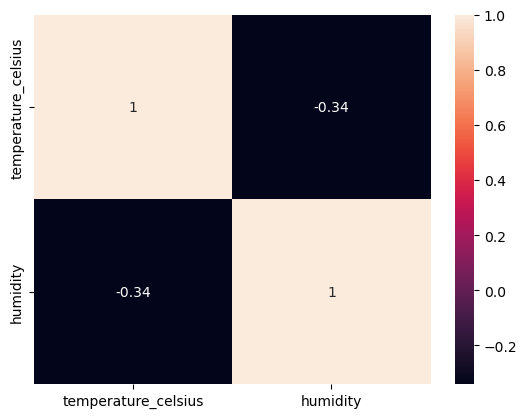

In [50]:
sns.heatmap(corr,annot = True)

In [52]:
df.columns

Index(['temperature_celsius', 'humidity'], dtype='object')

In [53]:
#Dividing the data into training and testing (X and Y)

In [10]:
# Independent Variable

X = df[['temperature_celsius']]

In [54]:
X

,temperature_celsius
0,26.6
1,19.0
2,23.0
3,6.3
4,26.0
...,...
152797,18.1
152798,34.3
152799,22.9
152800,14.3


In [55]:
# Dependent Variable

y = df['humidity']

In [56]:
y

0         24
1         94
2         29
3         61
4         89
          ..
152797    96
152798    63
152799    17
152800    58
152801    42
Name: humidity, Length: 152802, dtype: int64

In [57]:
#splitting the variables for training and testing 

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
X_train

,temperature_celsius
74538,28.7
10254,33.1
10557,29.0
58345,32.1
35323,13.8
...,...
119879,-23.8
103694,5.2
131932,26.6
146867,28.4


In [17]:
X_test

,temperature_celsius
135998,25.1
98624,15.4
151989,26.3
60529,14.1
63062,8.3
...,...
8046,42.8
56014,16.3
90749,14.6
125242,24.4


In [18]:
y_train

74538      77
10254      26
10557      84
58345      30
35323      50
         ... 
119879     57
103694    100
131932     78
146867     84
121958     48
Name: humidity, Length: 122241, dtype: int64

In [19]:
y_test

135998     83
98624      72
151989     94
60529      88
63062      27
         ... 
8046       20
56014      68
90749      85
125242     19
98401     100
Name: humidity, Length: 30561, dtype: int64

In [20]:
model = LinearRegression()

In [21]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred = model.predict(X_test)

In [32]:
y_pred

array([63.7467032 , 71.97521562, 62.7287429 , ..., 72.65385582,
       64.34051337, 67.8185444 ], shape=(30561,))

In [34]:
model.score(X_train,y_train)

0.11544398146692891

In [35]:
i = model.intercept_

In [36]:
i

np.float64(85.03903946851648)

In [37]:
c = model.coef_

In [38]:
c

array([-0.84830025])

In [39]:
# y = a+bx
# y = 85.03903946851648+-0.84830025(30)

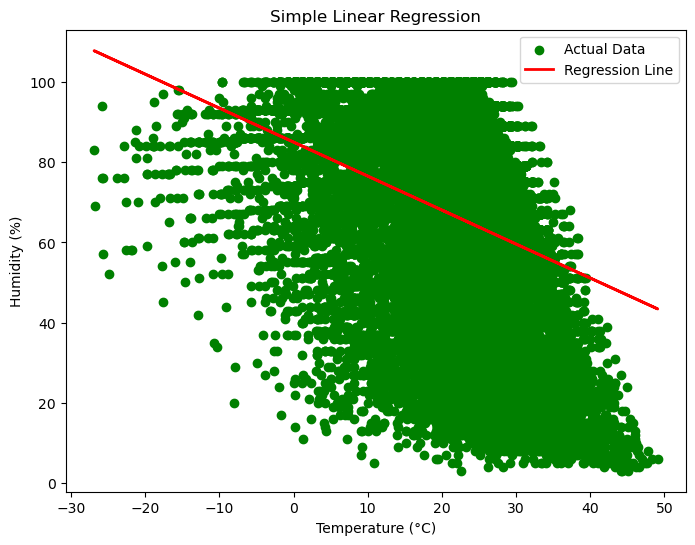

In [70]:
plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, color='green', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.title("Simple Linear Regression")
plt.legend()

plt.show()

In [67]:
p1 = model.predict([[30]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [68]:
p1

array([59.59003197])